# Train XGBoost Model

## Motivation
**XGBoost** was chosen for this task for a few main reasons:

1. **High Performance** — It naturally captures complex, non-linear patterns by building a sequence of trees where each corrects the errors of the previous one.
2. **Imbalance Handling** — Our dataset is 80/20. XGBoost uses the `scale_pos_weight` parameter to heavily penalize missed alarms (False Negatives).
3. **Robustness** — It doesn't require feature scaling (`StandardScaler`) and automatically handles missing data.
4. **Interpretability** — Native `feature_importances_` allows us to easily find the top 20 features.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from time import time
from pathlib import Path
import warnings

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import matthews_corrcoef
from app.db.database import Database

warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)

In [19]:
df = pd.read_csv("../data/merged/merged_preprocessed.csv")

df['time'] = pd.to_datetime(df['time'], utc=True).dt.tz_convert("Europe/Kyiv")
df = df.sort_values(by=["region_id", "time"]).reset_index(drop=True)

drop_cols = ['date', 'region_city', 'year', 'month', 'day']
existing_drop_cols = [c for c in drop_cols if c in df.columns]
X = df.drop(columns=existing_drop_cols)

target = 'alarm'
y = X.pop(target)

X_features = X.drop(columns=['time'], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

print(f"shape: {X_train.shape}")

shape: (658790, 112)


In [20]:
scale_pos_weight_value = 3.48

xgb_model = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight_value,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

t0 = time()
xgb_model.fit(X_train, y_train)
print(f"Completed in: {time() - t0:.2f}s")

Completed in: 38.35s


In [21]:
ratio = (df['alarm'] == 0).sum() / (df['alarm'] == 1).sum()
scale_weight = round(ratio, 2)
print(f"scale_pos_weight: {scale_weight}")

model = Pipeline([
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_weight,
        enable_categorical=True,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

scores, cm = evaluate_model(model)

scale_pos_weight: 3.88

-------- Overall --------
Train F1 : 0.801 ± 0.051
Test  F1 : 0.670 ± 0.022
AUPRC    : 0.736 ± 0.037
Completed in: 104.84s


In [22]:
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)
y_prob_test = xgb_model.predict_proba(X_test)[:, 1]

train_f1 = f1_score(y_train, y_pred_train)
test_f1 = f1_score(y_test, y_pred_test)
auprc = average_precision_score(y_test, y_prob_test)

print("-------- Overall --------")
print(f"Train F1 : {train_f1:.3f}")
print(f"Test  F1 : {test_f1:.3f}")
print(f"AUPRC    : {auprc:.3f}")

cm = confusion_matrix(y_test, y_pred_test)

-------- Overall --------
Train F1 : 0.747
Test  F1 : 0.742
AUPRC    : 0.860


## Confusion Matrix — Baseline XGBoost

**What the metrics mean:**

* **True Negative (TN):** Model correctly predicted no alarm — safe hour correctly identified.
* **False Positive (FP):** Model predicted alarm but there was none — unnecessary alert (costs attention).
* **False Negative (FN):** Model predicted no alarm but an alarm occurred — missed threat (most dangerous).
* **True Positive (TP):** Model correctly predicted an alarm — correct warning issued.

XGBoost with `scale_pos_weight` should inherently shift predictions to minimize False Negatives, prioritizing Recall over Precision.

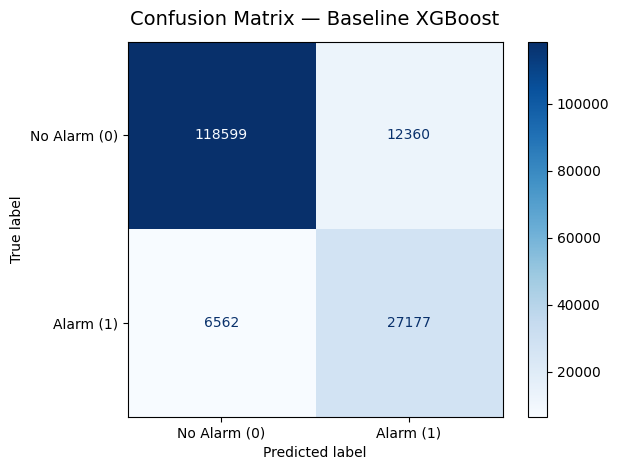

In [28]:
disp = ConfusionMatrixDisplay(cm, display_labels=["No Alarm (0)", "Alarm (1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Baseline XGBoost", fontsize=14, pad=12)
plt.grid(False)
plt.tight_layout()
plt.show()

# Hyperparameter Tuning — GridSearchCV

## Scoring metrics chosen

* **`f1`**: Balances Precision and Recall for our imbalanced 20/80 split.
* **`average_precision`**: Best for imbalanced binary classification. Summarizes Precision-Recall trade-off without being skewed by the large TN count.

## Parameters searched

* `n_estimators` (100, 300): Number of boosting rounds.
* `max_depth` (4, 6, 8): Maximum depth. Keeps individual learners relatively weak to prevent overfitting.
* `learning_rate` (0.05, 0.1): Step size shrinkage.
* `subsample` (0.8): Uses 80% of rows per tree, introducing randomness.

In [31]:
tscv_gs = TimeSeriesSplit(n_splits=3, gap=24 * 7)
scale_weight = scale_pos_weight_value 

param_grid = {
    "classifier__n_estimators":  [100, 300],
    "classifier__max_depth":     [4, 6, 8],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__subsample":     [0.8],
    "classifier__scale_pos_weight": [scale_weight],
}

X_gs = X.drop(columns=["time", "region_id"], errors='ignore')

model = Pipeline([
    ("classifier", XGBClassifier(objective='binary:logistic', random_state=42, n_jobs=-1))
])

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring={"f1": "f1", "average_precision": "average_precision"},
    refit="f1",
    cv=tscv_gs,
    n_jobs=1,
    verbose=2,
    return_train_score=True,
)

t0 = time()
grid_search.fit(X_gs, y)
print(f"\nGridSearchCV completed in: {time() - t0:.2f}s")

print("Best parameters:")
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")

print(f"\nBest CV F1       : {grid_search.best_score_:.4f}")
print(f"Best CV AUPRC    : {grid_search.cv_results_['mean_test_average_precision'][grid_search.best_index_]:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END classifier__learning_rate=0.05, classifier__max_depth=4, classifier__n_estimators=100, classifier__scale_pos_weight=3.48, classifier__subsample=0.8; total time=   4.0s
[CV] END classifier__learning_rate=0.05, classifier__max_depth=4, classifier__n_estimators=100, classifier__scale_pos_weight=3.48, classifier__subsample=0.8; total time=   6.2s
[CV] END classifier__learning_rate=0.05, classifier__max_depth=4, classifier__n_estimators=100, classifier__scale_pos_weight=3.48, classifier__subsample=0.8; total time=   9.0s
[CV] END classifier__learning_rate=0.05, classifier__max_depth=4, classifier__n_estimators=300, classifier__scale_pos_weight=3.48, classifier__subsample=0.8; total time=   6.9s
[CV] END classifier__learning_rate=0.05, classifier__max_depth=4, classifier__n_estimators=300, classifier__scale_pos_weight=3.48, classifier__subsample=0.8; total time=  13.1s
[CV] END classifier__learning_rate=0.05, classifier__m

In [32]:
cv_results = pd.DataFrame(grid_search.cv_results_)

top5 = (
    cv_results
    .sort_values("mean_test_f1", ascending=False)
    .head(5)
    [[
        "param_classifier__n_estimators",
        "param_classifier__max_depth",
        "param_classifier__learning_rate",
        "mean_test_f1",
        "mean_test_average_precision",
    ]]
    .rename(columns=lambda c: c.replace("param_classifier__", "").replace("mean_test_", ""))
    .reset_index(drop=True)
)

top5

,n_estimators,max_depth,learning_rate,f1,average_precision
0,300,8,0.10,0.785941,0.877838
1,300,8,0.05,0.770853,0.867540
2,300,6,0.10,0.760419,0.861771
3,100,8,0.10,0.756927,0.857121
4,300,6,0.05,0.742173,0.848207


In [33]:
tuned_xgb_model = grid_search.best_estimator_

def evaluate_model(pipeline, X=X, y=y, n_splits: int = 5, gap: int = 24 * 7):
    fold_train_f1, fold_test_f1 = [[] for _ in range(n_splits)], [[] for _ in range(n_splits)]
    fold_auprc, fold_mcc = [[] for _ in range(n_splits)], [[] for _ in range(n_splits)]
    all_y_true, all_y_pred = [], []
    regions = sorted(X["region_id"].unique())
    t0 = time()

    for region_id in regions:
        mask_region = X["region_id"] == region_id
        unique_hours = X.loc[mask_region, "time"].sort_values().unique()
        tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)

        for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_hours)):
            train_mask = X["time"].isin(unique_hours[train_idx]) & mask_region
            test_mask  = X["time"].isin(unique_hours[test_idx])  & mask_region

            X_train, X_test = X[train_mask].drop(columns=["time", "region_id"]), X[test_mask].drop(columns=["time", "region_id"])
            y_train, y_test = y[train_mask], y[test_mask]

            if len(X_test) == 0: continue

            pipeline.fit(X_train, y_train)
            y_pred_train, y_pred_test = pipeline.predict(X_train), pipeline.predict(X_test)
            pred_test_proba = pipeline.predict_proba(X_test)[:, 1]

            y_train_cls, y_test_cls = (y_train > 0).astype(int), (y_test > 0).astype(int)

            fold_train_f1[fold].append(f1_score(y_train_cls, y_pred_train, zero_division=0))
            fold_test_f1[fold].append(f1_score(y_test_cls, y_pred_test, zero_division=0))
            fold_auprc[fold].append(average_precision_score(y_test_cls, pred_test_proba))
            fold_mcc[fold].append(matthews_corrcoef(y_test_cls, y_pred_test))

            all_y_true.extend(y_test_cls)
            all_y_pred.extend(y_pred_test)

    train_f1_m = [np.mean(s) for s in fold_train_f1 if s]
    test_f1_m  = [np.mean(s) for s in fold_test_f1  if s]
    auprc_m    = [np.mean(s) for s in fold_auprc if s]
    mcc_m      = [np.mean(s) for s in fold_mcc if s]

    print("\n-------- Overall --------")
    print(f"Train F1 : {np.mean(train_f1_m):.3f} ± {np.std(train_f1_m):.3f}")
    print(f"Test  F1 : {np.mean(test_f1_m):.3f} ± {np.std(test_f1_m):.3f}")
    print(f"AUPRC    : {np.mean(auprc_m):.3f} ± {np.std(auprc_m):.3f}")
    print(f"Completed in: {time() - t0:.2f}s")

    return {"train_f1": train_f1_m, "test_f1": test_f1_m, "auprc": auprc_m}, confusion_matrix(all_y_true, all_y_pred)

metrics_dict, cm_tuned = evaluate_model(tuned_xgb_model, n_splits=3)


-------- Overall --------
Train F1 : 1.000 ± 0.000
Test  F1 : 0.662 ± 0.017
AUPRC    : 0.726 ± 0.027
Completed in: 259.15s


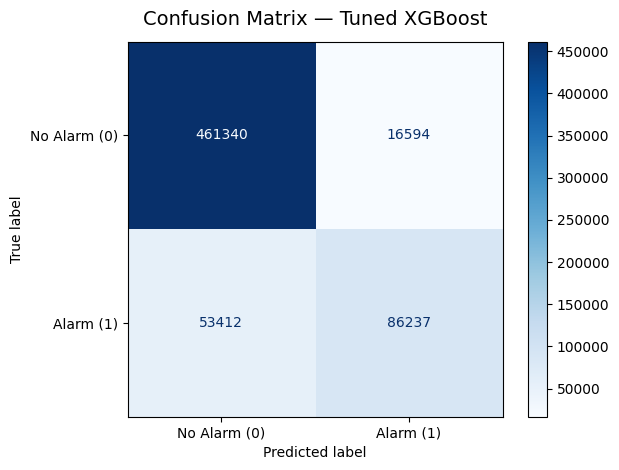

In [34]:
disp_tuned = ConfusionMatrixDisplay(
    cm_tuned,
    display_labels=["No Alarm (0)", "Alarm (1)"]
)
disp_tuned.plot(cmap="Blues", values_format='d')
plt.title(
    "Confusion Matrix — Tuned XGBoost",
    fontsize=14, pad=12
)
plt.grid(False)
plt.tight_layout()
plt.show()

In [35]:
model_path = Path("app/models/1_xgboost_v1.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)

with open(model_path, "wb") as f:
    pickle.dump(tuned_xgb_model, f)

# Top 20 features and weights

XGBoost provides **feature importance** based on "gain" (the average improvement in accuracy brought by a feature to the branches it is on). This tells us which features contribute the most to the model's predictive power.

In [36]:
feature_names = X.drop(columns=["time", "region_id"]).columns.tolist()

importances = tuned_xgb_model.named_steps["classifier"].feature_importances_

feat_imp = (
    pd.DataFrame({"feature": feature_names, "weight": importances})
    .sort_values("weight", ascending=False)
    .reset_index(drop=True)
)

top20 = feat_imp.head(20)
top20

,feature,weight
0,alarm_status_1h_ago,0.338786
1,neighbor_alarm_count,0.024981
2,isw_cluster_9,0.023947
3,nlp_відбій,0.023443
4,nlp_бпла,0.011182
5,isw_cluster_2,0.009440
6,nlp_повітряна_тривога,0.009017
7,alarm_status_18h_ago,0.008646
8,precip,0.008642
9,isw_cluster_1,0.008383


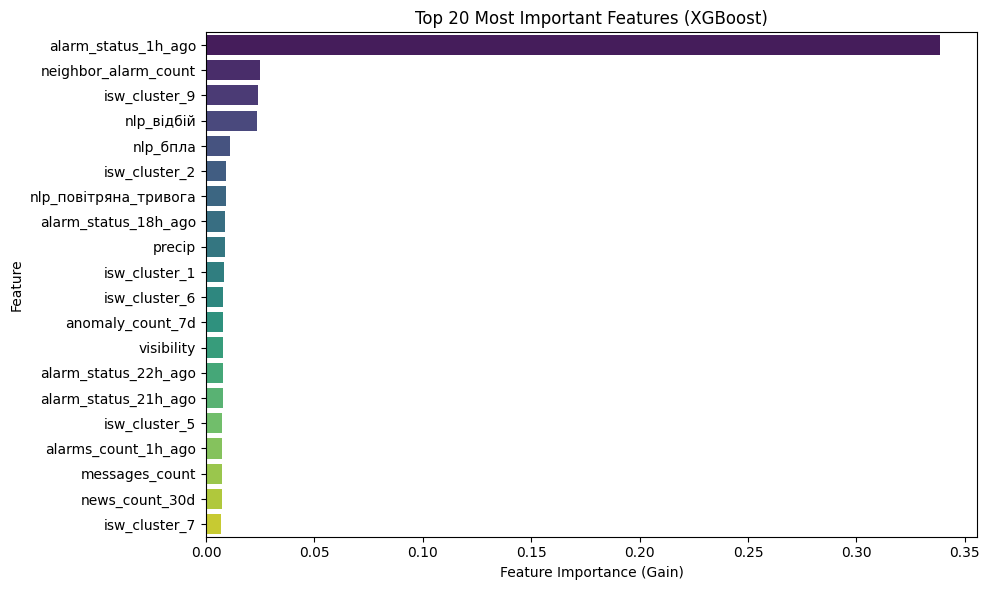

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top20,
    x="weight",
    y="feature",
    palette="viridis"
)

plt.title("Top 20 Most Important Features (XGBoost)")
plt.xlabel("Feature Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
with Database("app/db/database.db") as db:
    new_data = db.get_merged(start_date='2024-01-01')
def check_on_new_data(pipeline, new_data=new_data):
    X_new = new_data.copy()
    target = 'alarm' 
    y_new = X_new.pop(target)
    
    X_new_features = X_new.drop(columns=["time", "region_id"], errors="ignore")
    for col in X_gs.columns:
        if col not in X_new_features.columns:
            X_new_features[col] = 0
    X_new_features = X_new_features[X_gs.columns]
    
    y_preds = pipeline.predict(X_new_features)
    score = f1_score(y_new, y_preds)
    
    ConfusionMatrixDisplay(confusion_matrix(y_new, y_preds)).plot(cmap="Blues", values_format='d')
    plt.title(f"F1 Score on New Data: {score:.4f}")
    plt.grid(False)
    plt.show()
    
    res = X_new[['region_id', 'time']].copy() if 'region_id' in X_new.columns else pd.DataFrame()
    res['alarm'] = y_new
    res['prediction'] = y_preds
    res['pred_prob_1'] = pipeline.predict_proba(X_new_features)[:, 1]
    
    return res

FileNotFoundError: Region hierarchy file not found: data\alarms\regions_list.json

In [48]:
res_model = check_on_new_data(tuned_xgb_model)

NameError: name 'check_on_new_data' is not defined